# Time Series Forecasting

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from IPython.display import display
from darts import TimeSeries
from darts.models import ARIMA, ExponentialSmoothing, XGBModel, Chronos2Model
from darts.utils.likelihood_models.torch import QuantileRegression
from darts.metrics import mape, mae, mse, mql
import warnings
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:.2f}'.format

## Data

In [89]:
df = pd.read_csv('./datasets/electricity_consumption_and_production.csv', parse_dates=['DateTime'])
df = df.set_index('DateTime')

display(df.head())
print(df.shape)

df = df[['Consumption']]
df_daily = df.resample('D').mean()
df_daily['Consumption'] = df_daily['Consumption'].interpolate(method='linear')

display(df_daily.head())
print(df_daily.shape)

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


(54161, 9)


,Consumption
DateTime,
2019-01-01,5924.48
2019-01-02,6322.04
2019-01-03,7254.08
2019-01-04,7635.08
2019-01-05,7423.52


(2270, 1)


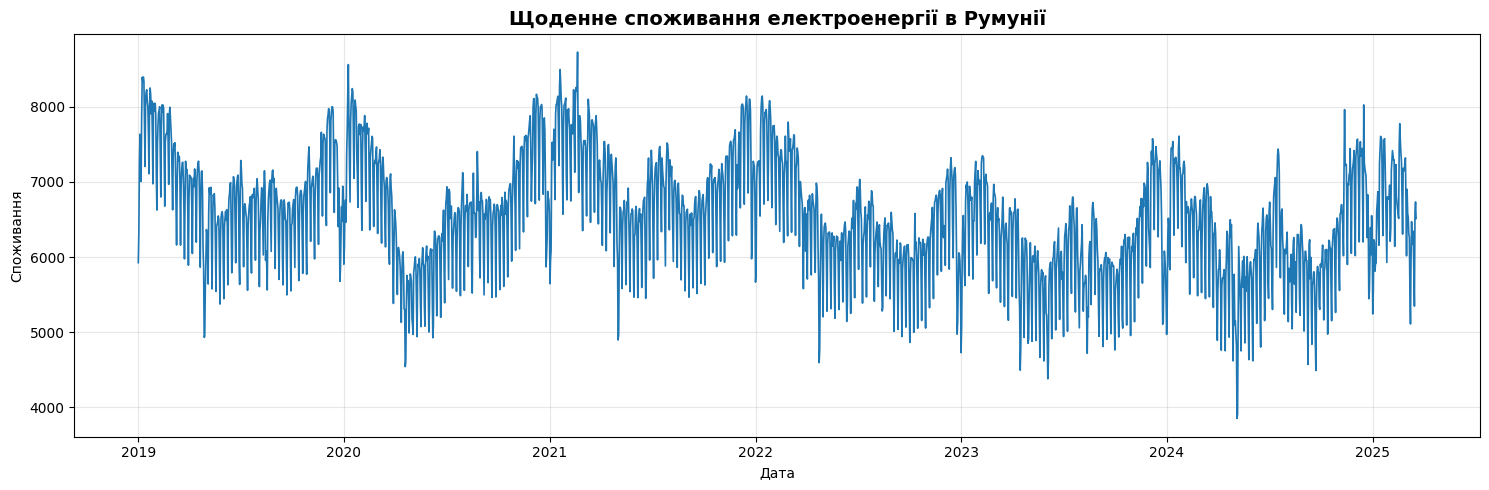

In [79]:
plt.figure(figsize=(15, 5))
plt.plot(df_daily.index, df_daily['Consumption'], color='#1f77b4', linewidth=1.2)
plt.title('Щоденне споживання електроенергії в Румунії', fontsize=14, fontweight='bold')
plt.ylabel('Споживання')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Seasonal decomposition

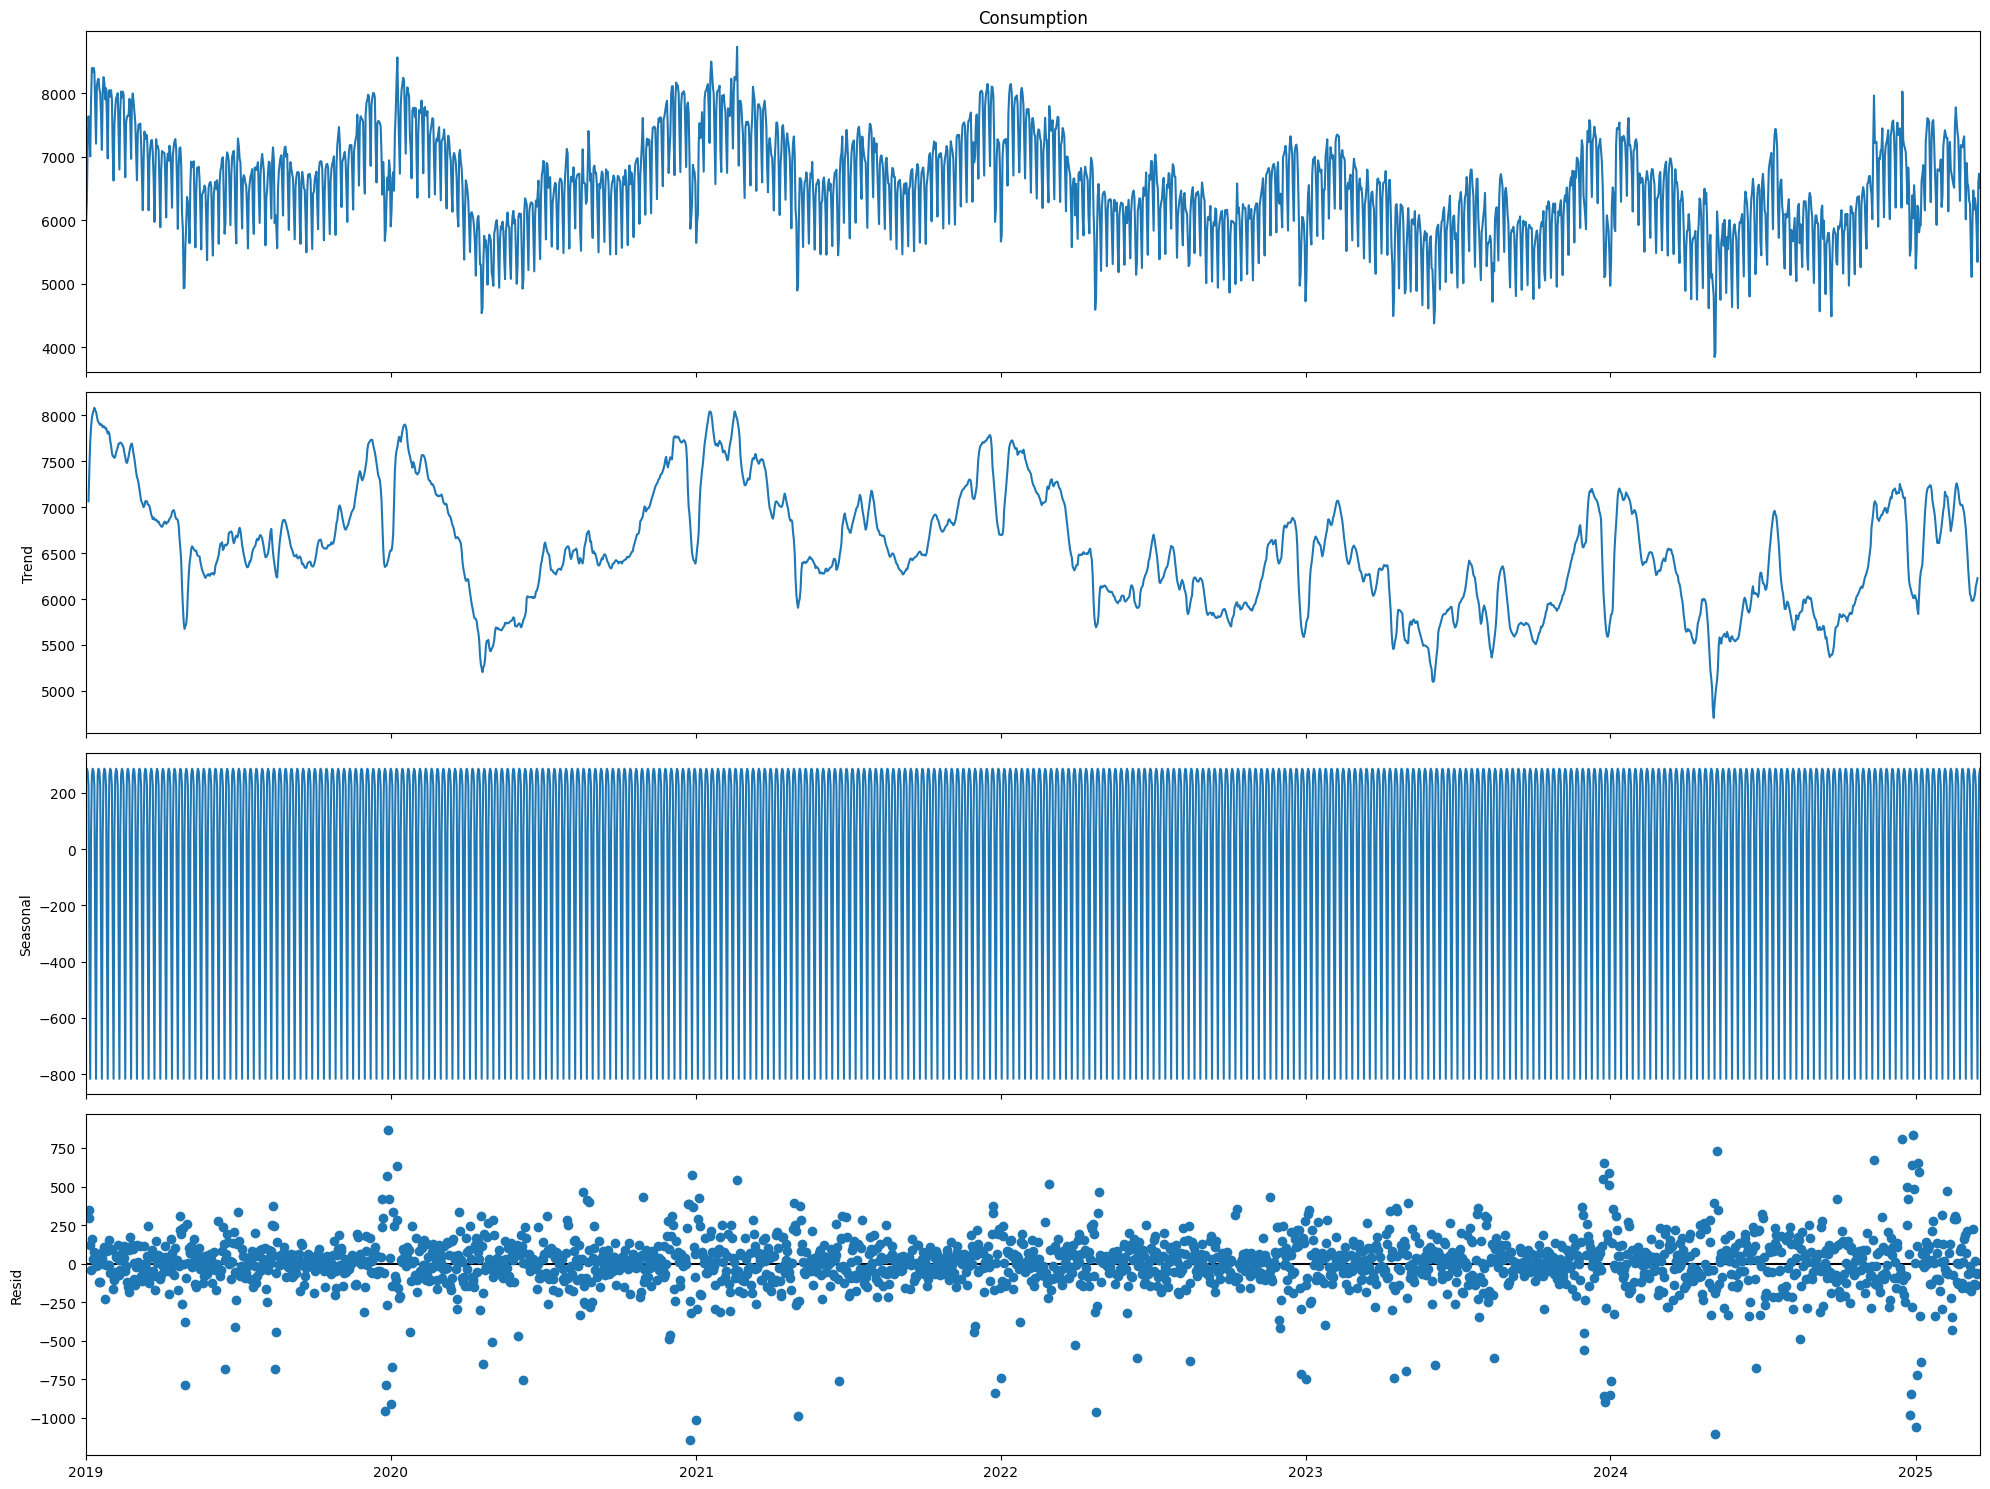

In [80]:
decomposition = seasonal_decompose(df_daily['Consumption'], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(20, 15)
plt.tight_layout()
plt.show()

## ADF

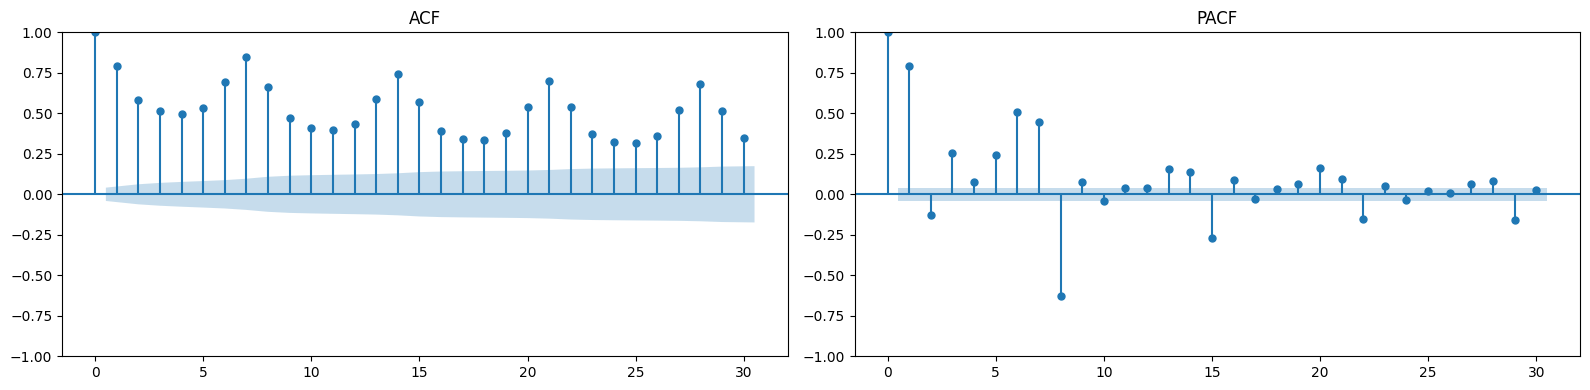

,ADF Statistic,p-value,Stationary
Consumption (Daily),-3.388400,0.011400,True


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_daily['Consumption'],  lags=30, ax=axes[0], title="ACF")
plot_pacf(df_daily['Consumption'], lags=30, ax=axes[1], title="PACF")
plt.tight_layout()
plt.show()


def adf_stationarity_test(series: pd.Series) -> dict:
    result = adfuller(series)
    p_value = result[1]
    return {
        "ADF Statistic": round(result[0], 4),
        "p-value": round(p_value, 4),
        "Stationary": p_value < 0.05,
    }

adf_results = {"Consumption (Daily)": adf_stationarity_test(df_daily['Consumption'])}

display(
    pd.DataFrame(adf_results).T.style.map(
        lambda v: "background-color: #c6efce" if v is True else
                  "background-color: #ffc7ce" if v is False else "",
        subset=["Stationary"]
    )
)

## Train-test split

Тренувальна вибірка : 2225 днів
Валідаційна вибірка : 45 днів


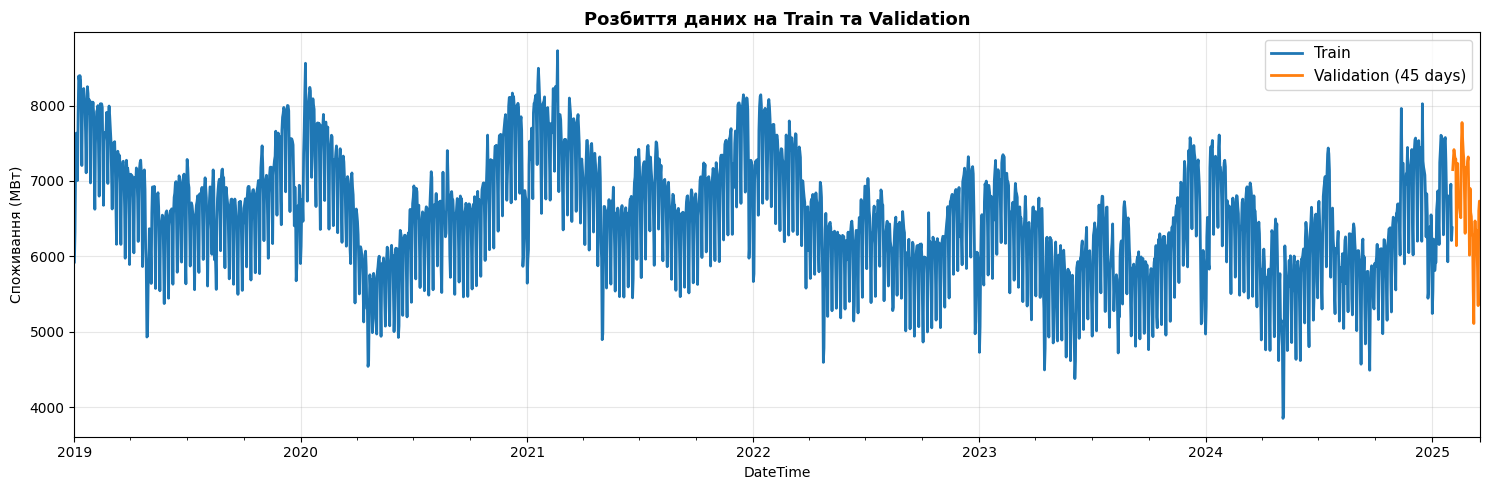

In [90]:
series = TimeSeries.from_dataframe(df_daily, value_cols=['Consumption'])

TEST_SIZE_MAX = 45
train, val = series[:-TEST_SIZE_MAX], series[-TEST_SIZE_MAX:]

print(f"Тренувальна вибірка : {len(train)} днів")
print(f"Валідаційна вибірка : {len(val)} днів")

plt.figure(figsize=(15, 5))
train.plot(label='Train')
val.plot(label='Validation (45 days)')
plt.legend(fontsize=11)
plt.title("Розбиття даних на Train та Validation", fontsize=13, fontweight='bold')
plt.ylabel("Споживання (МВт)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Models

In [ ]:
model_sarima = ARIMA(p=1, d=1, q=1, seasonal_order=(1, 1, 1, 7))

model_es = ExponentialSmoothing(seasonal_periods=7)

model_xgb = XGBModel(lags=14)

model_chronos = Chronos2Model(
    model_name="amazon/chronos-bolt-mini",
    input_chunk_length=90,
    output_chunk_length=TEST_SIZE_MAX,
    likelihood=QuantileRegression([0.1, 0.5, 0.9]),
)

models = {
    "SARIMA": model_sarima,
    "Holt-Winters": model_es,
    "XGBoost":  model_xgb,
    "Chronos-Bolt-Mini": model_chronos,
}

for name, model in models.items():
    model.fit(train)
    print(f"  ✓  {name}")

  ✓  SARIMA
  ✓  Holt-Winters
  ✓  XGBoost


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


  ✓  Chronos-Bolt-Mini


## Visualization functions

In [ ]:
val_fixed = val.map(lambda x: np.where(x == 0, 0.001, x))

Q_LOW, Q_HIGH = 0.1, 0.9
PROB_MODELS = {"SARIMA", "Holt-Winters", "Chronos-Bolt-Mini"}

def calculate_metrics(actual_ts: TimeSeries, pred_ts: TimeSeries,
                      q_low: float = Q_LOW, q_high: float = Q_HIGH) -> dict:
    is_prob = pred_ts.n_samples > 1
    median  = pred_ts.quantile(0.5) if is_prob else pred_ts

    metrics = {
        "MAPE (%)": round(mape(actual_ts, median), 3),
        "MAE": round(mae(actual_ts, median), 3),
        "MSE": round(mse(actual_ts, median), 3),
        f"QL@{q_low}": round(mql(actual_ts, pred_ts, q=q_low), 3) if is_prob else None,
        f"QL@{q_high}": round(mql(actual_ts, pred_ts, q=q_high), 3) if is_prob else None,
    }
    return metrics


def visualize_horizon_forecast(
    horizon: int,
    predictions: dict,
    train_ts: TimeSeries,
    actual_ts: TimeSeries,
    q_low: float = Q_LOW,
    q_high: float = Q_HIGH,
) -> dict:
    n = len(predictions)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4.5 * n))
    if n == 1:
        axes = [axes]

    train_crop = train_ts[-60:]
    all_metrics = {}

    for ax, (model_name, pred_ts) in zip(axes, predictions.items()):
        is_prob = pred_ts.n_samples > 1
        median  = pred_ts.quantile(0.5) if is_prob else pred_ts

        train_crop.to_series().plot(ax=ax, label="Тренувальні дані",
                                    color="steelblue", lw=1.8)
        actual_ts.to_series().plot(ax=ax, label="Фактичні значення",
                                   color="#2ca02c", lw=1.8)
        median.to_series().plot(   ax=ax, label="Прогноз",
                                   color="tomato",   lw=1.8)

        if is_prob:
            low  = pred_ts.quantile(q_low).values()[:, 0]
            high = pred_ts.quantile(q_high).values()[:, 0]
            ci_pct = int((1 - 2 * q_low) * 100)
            ax.fill_between(pred_ts.time_index, low, high,
                            alpha=0.25, color="tomato",
                            label=f"{ci_pct}% ДІ")

        ax.set_title(f"Горизонт: {horizon} днів  ·  Модель: {model_name}",
                     fontsize=12, fontweight="bold")
        ax.set_ylabel("Споживання (МВт)")
        ax.set_xlabel("")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", fontsize=10)

        metrics = calculate_metrics(actual_ts, pred_ts, q_low, q_high)
        all_metrics[model_name] = metrics

        summary = f"MAPE {metrics['MAPE (%)']:.2f}%  |  MAE {metrics['MAE']:.1f}  |  MSE {metrics['MSE']:.1f}"
        if metrics.get(f"QL@{q_low}") is not None:
            summary += (f"  |  QL@{q_low} {metrics[f'QL@{q_low}']:.2f}"
                        f"  QL@{q_high} {metrics[f'QL@{q_high}']:.2f}")

        ax.text(0.99, 0.97, summary, transform=ax.transAxes, fontsize=9.5,
                ha="right", va="top",
                bbox=dict(facecolor="white", alpha=0.92, edgecolor="#999",
                          boxstyle="round,pad=0.5"))

    fig.suptitle(f"Прогноз на {horizon} днів", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return all_metrics

## Prediction for 15, 30, 45 days

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:04<00:00,  0.21it/s]


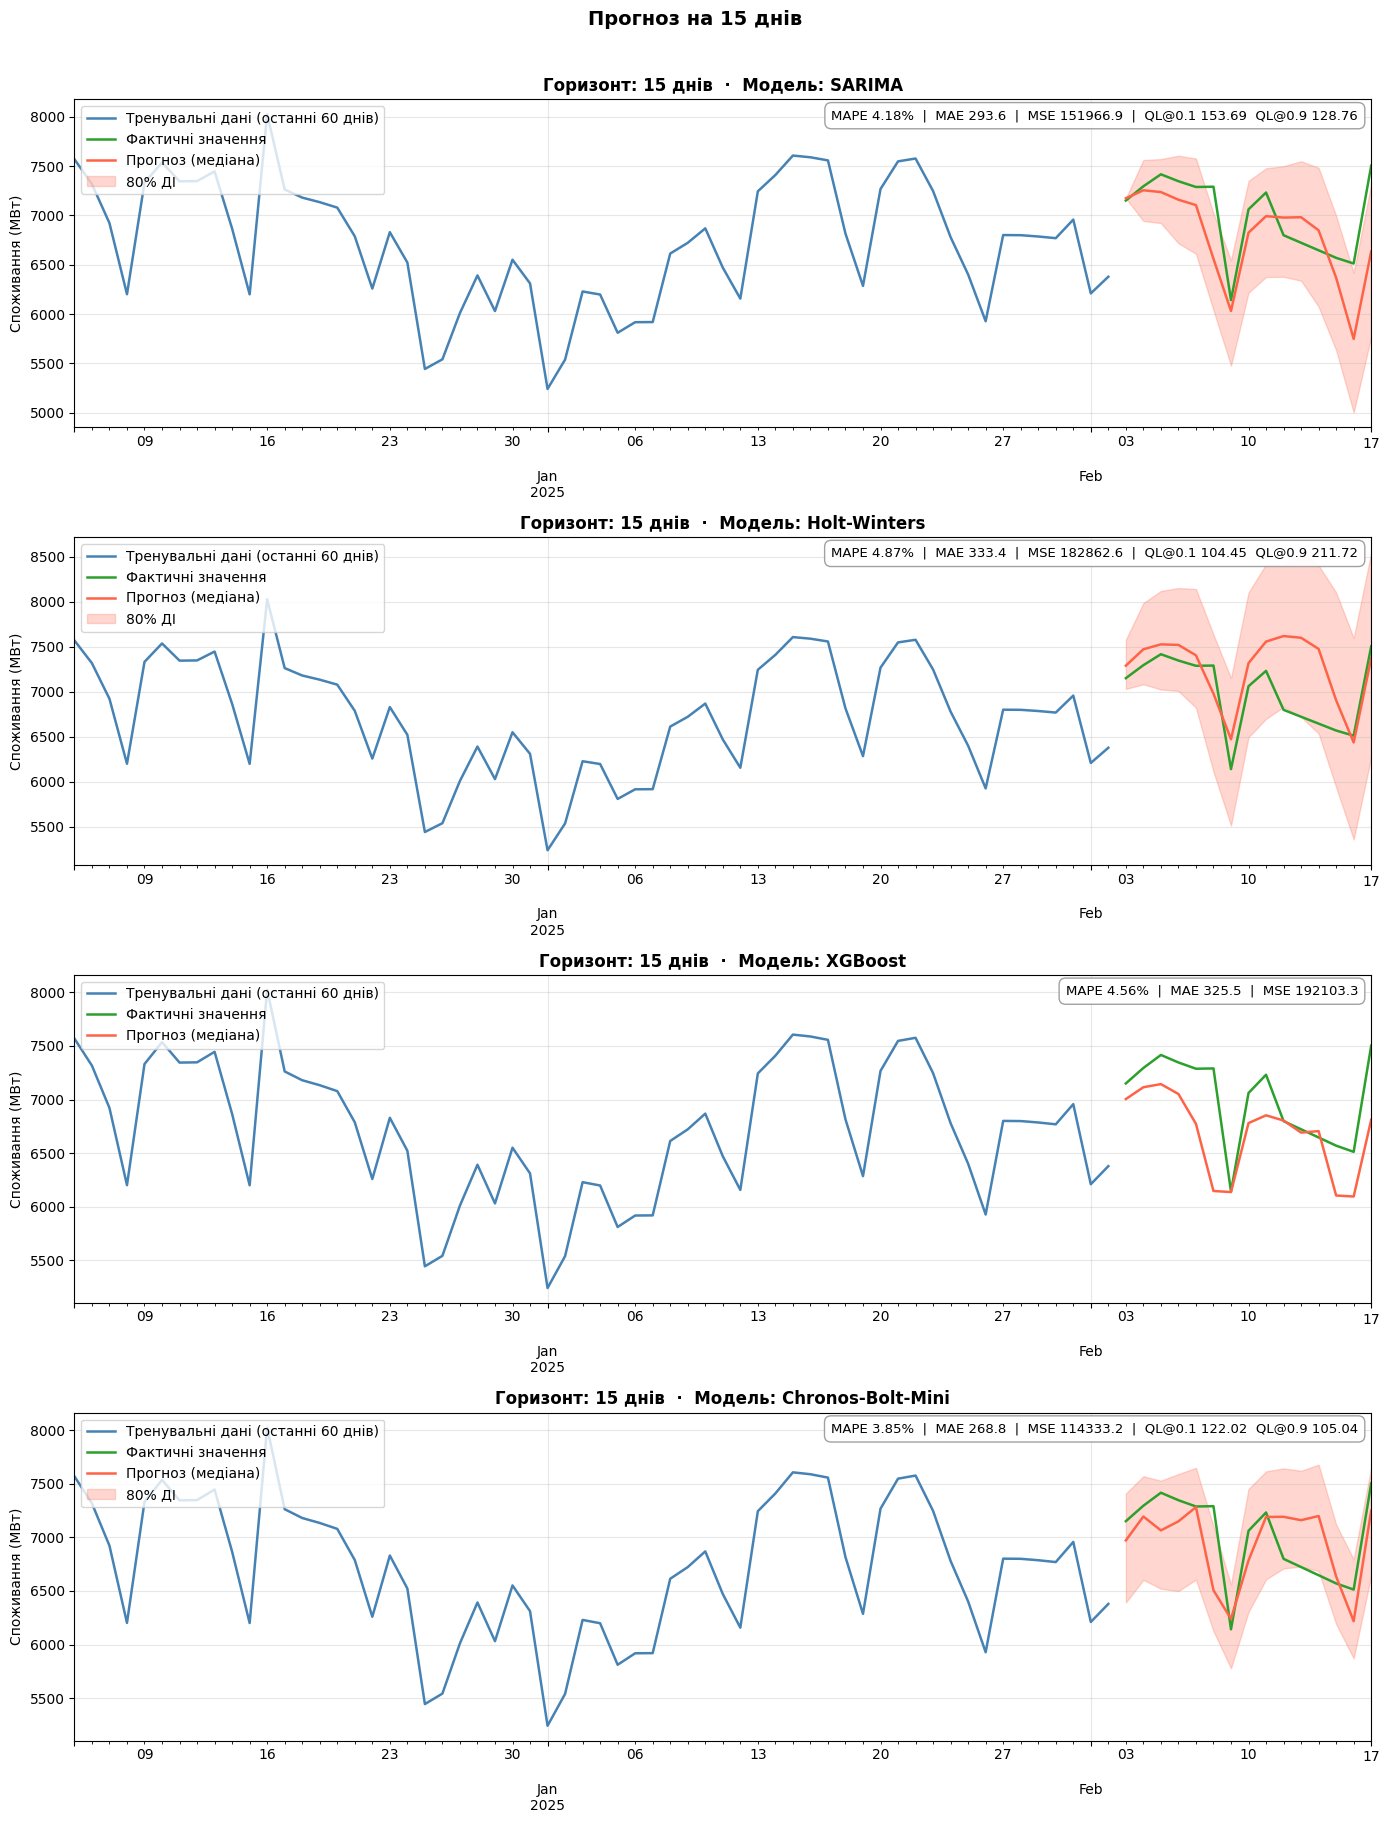

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:03<00:00,  0.28it/s]


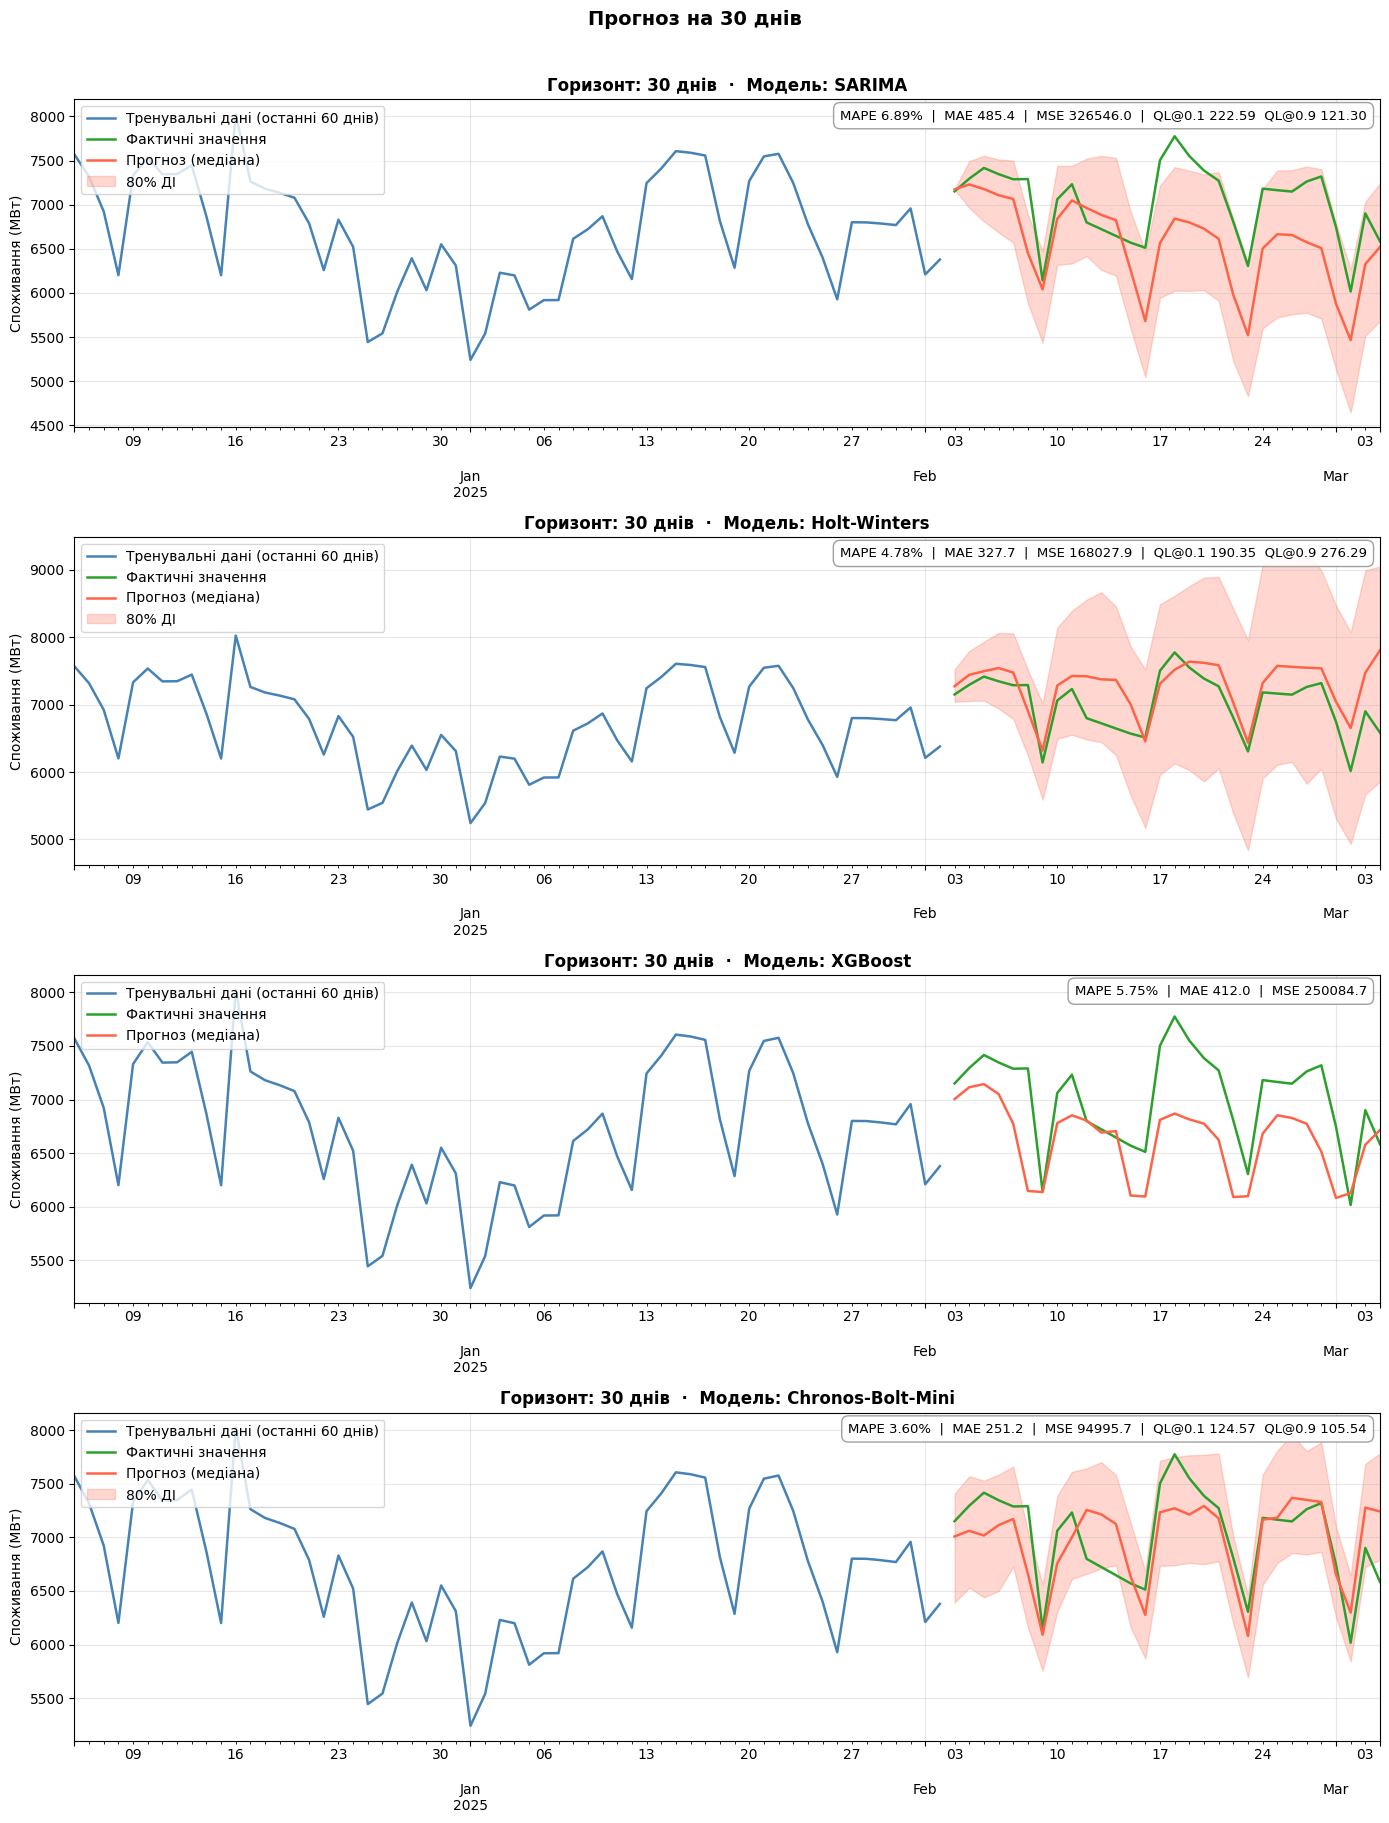

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:03<00:00,  0.28it/s]


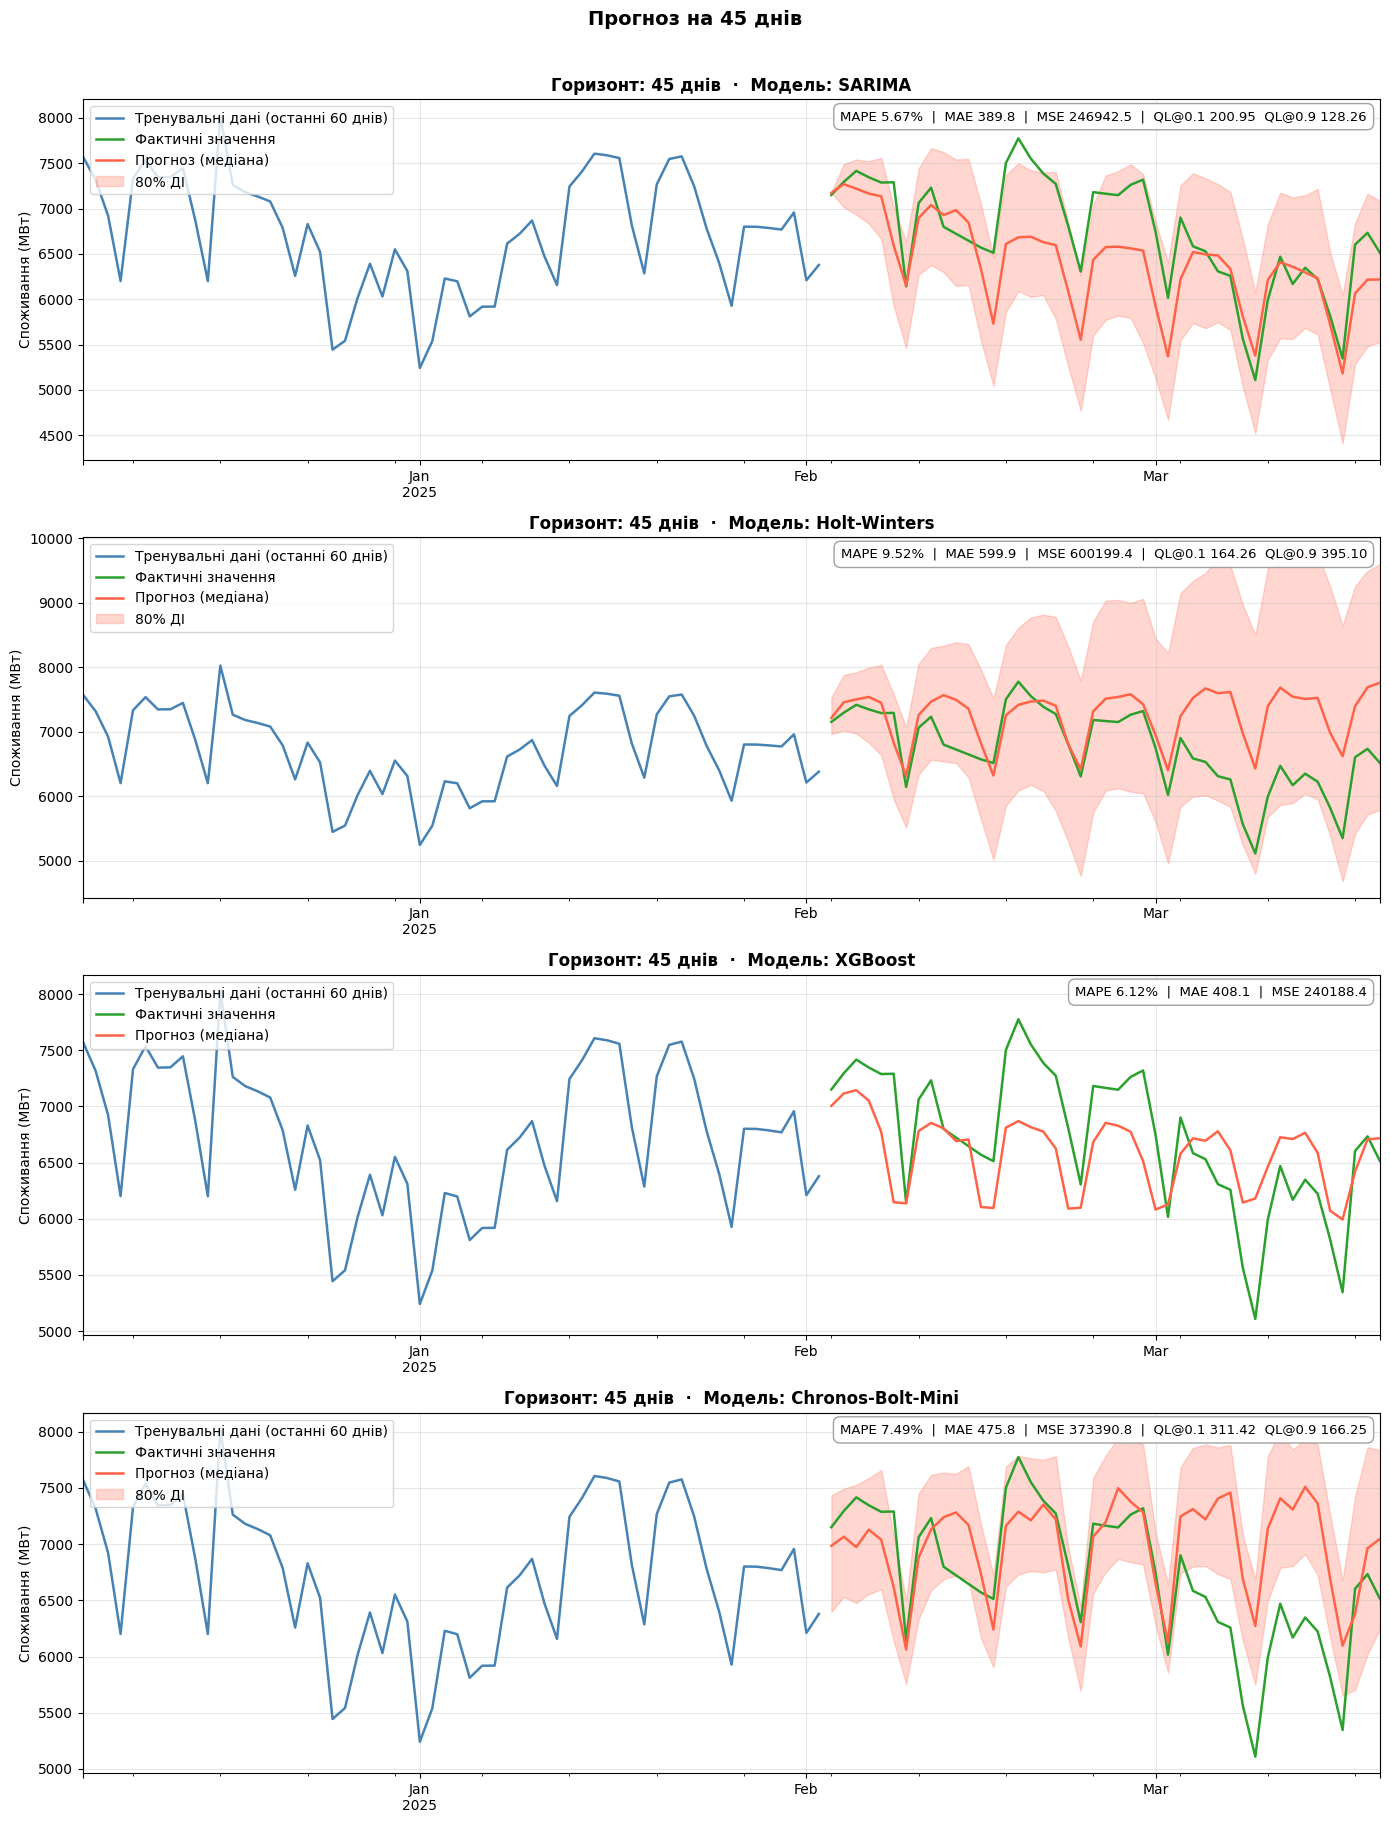

In [ ]:
horizons = [15, 30, 45]

all_predictions: dict[int, dict] = {}
all_horizons_metrics: dict[int, dict] = {}

for h in horizons:
    val_h  = val_fixed[:h]
    preds_h = {}

    for name, model in models.items():
        if name in PROB_MODELS:
            preds_h[name] = model.predict(n=h, num_samples=100)
        else:
            preds_h[name] = model.predict(n=h)

    all_predictions[h] = preds_h
    all_horizons_metrics[h] = visualize_horizon_forecast(h, preds_h, train, val_h)

## Results

In [ ]:
METRICS_TO_SHOW = ["MAPE (%)", "MAE", "MSE"]

rows = []
for h in horizons:
    for model_name, metrics in all_horizons_metrics[h].items():
        row = {"Модель": model_name, "Горизонт": f"{h} днів"}
        for m in METRICS_TO_SHOW:
            row[m] = metrics[m]
        rows.append(row)

df_summary = pd.DataFrame(rows)

pivot = df_summary.pivot_table(
    index="Модель",
    columns="Горизонт",
    values=METRICS_TO_SHOW,
)
pivot.columns = pivot.columns.swaplevel(0, 1)
col_order = [(f"{h} днів", m) for h in horizons for m in METRICS_TO_SHOW]
pivot = pivot[col_order]
pivot.columns.names = ["Горизонт", "Метрика"]

def highlight_best(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in df.columns:
        styles.loc[df[col] == df[col].min(), col] = "font-weight: bold"
    return styles

display(
    pivot.style
    .apply(highlight_best, axis=None)
    .format("{:.2f}")
)

ql_rows = []
for h in horizons:
    for model_name, metrics in all_horizons_metrics[h].items():
        ql_lo = metrics.get(f"QL@{Q_LOW}")
        ql_hi = metrics.get(f"QL@{Q_HIGH}")
        if ql_lo is not None:
            ql_rows.append({
                "Модель": model_name,
                "Горизонт": f"{h} днів",
                f"QL@{Q_LOW}": ql_lo,
                f"QL@{Q_HIGH}": ql_hi,
            })

if ql_rows:
    df_ql = pd.DataFrame(ql_rows)
    pivot_ql = df_ql.pivot_table(
        index="Модель",
        columns="Горизонт",
        values=[f"QL@{Q_LOW}", f"QL@{Q_HIGH}"],
    )
    pivot_ql.columns = pivot_ql.columns.swaplevel()
    ql_col_order = [(f"{h} днів", q) for h in horizons for q in [f"QL@{Q_LOW}", f"QL@{Q_HIGH}"]]
    pivot_ql = pivot_ql[ql_col_order]
    pivot_ql.columns.names = ["Горизонт", "Метрика"]

    display(
        pivot_ql.style
        .apply(highlight_best, axis=None)
        .format("{:.3f}")
    )